<!DOCTYPE html><html lang="zh-CN"><head><meta http-equiv="Content-Type" content="text/html; charset=utf-8"><meta http-equiv="X-UA-Compatible" content="IE=edge" /><meta name="renderer" content="webkit" /><meta http-equiv="Cache-Control" content="no-transform" /><meta http-equiv="Cache-Control" content="no-siteapp" /><meta name="format-detection" content="telephone=no" />
    <title>广州楼盘|新开盘楼盘|房价信息_广州楼盘(广州链家新房)</title>
    <meta name="description" content="广州链家新房频道,为你提供大量真实优质的广州新开盘楼盘、新房房价等信息快速查询,创造最佳新房购房体验." />
    <meta name="keywords" content="广州楼盘,广州房价" />
<link href="/favicon.ico" type="image/x-icon" rel=icon><link href="/favicon.ico" type="image/x-icon" rel="shortcut icon"><link rel="stylesheet" href="//s1.ljcdn.com/phoenix/static/dist/common/site.css?_v=20220920141622"><link rel="alternate" media="only screen and (max-width: 640px)" href="" >
    <link rel="stylesheet" href="//s1.ljcdn.com/phoenix/static/dist/pages/list/index.css?_v=20220920141622">
<script>

</script><!--[if lt IE
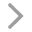

In [ ]:
#一、全国新房数据
# 0、测试爬虫：
import requests
from requests.adapters import HTTPAdapter

s = requests.session()


# max_retries=3 重试3次
s.mount('http://', HTTPAdapter(max_retries=3))
s.mount('https://', HTTPAdapter(max_retries=3))


url = "https://gz.fang.lianjia.com/loupan/pg1/"
r = s.request("GET", url=url, timeout=15)
print(r.text)

In [9]:
#1、新房数据
#方法：通过网址模板逐页发送请求，然后使用json包进行解析
#（1）获取链家网站上城市和页数信息（每页10条信息）
import codecs
import requests
from lxml import etree
import random
import json
import pandas as pd
from pandas import json_normalize
import math
import re
import time
from requests.adapters import HTTPAdapter
import sys 

sys.setrecursionlimit(1000000)

#User-Agent，用来模拟浏览器，爬虫本质上是一个下载器，需要通过加入一些浏览器的标识信息使得服务器以为这是一个来自浏览器的请求。
#1.随机获取一个userAgent
def getUserAgent():
    UA_list=["Mozilla/5.0 (Windows NT 10.0; WOW64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/55.0.2883.87 Safari/537.36",
        "Mozilla/5.0 (iPhone; CPU iPhone OS 7_1_2 like Mac OS X) App leWebKit/537.51.2 (KHTML, like Gecko) Version/7.0 Mobile/11D257 Safari/9537.53",
        "Mozilla/5.0 (Windows; U; Windows NT 5.2) AppleWebKit/525.13 (KHTML, like Gecko) Chrome/0.2.149.27 Safari/525.13",
        "Mozilla/4.0 (compatible; MSIE 8.0; Windows NT 5.1; Trident/4.0; Mozilla/4.0 (compatible; MSIE 6.0; Windows NT 5.1; SV1) ;  QIHU 360EE)",
        "Mozilla/4.0 (compatible; MSIE 7.0; Windows NT 5.1; Trident/4.0; Mozilla/4.0 (compatible; MSIE 6.0; Windows NT 5.1; SV1) ; Maxthon/3.0)",
        "Mozilla/5.0 (Macintosh; U; Intel Mac OS X 10_6_8; en-us) AppleWebKit/534.50 (KHTML, like Gecko) Version/5.1 Safari/534.50",
        "Mozilla/5.0 (Macintosh; U; IntelMac OS X 10_6_8; en-us) AppleWebKit/534.50 (KHTML, like Gecko) Version/5.1Safari/534.50",
        "Mozilla/5.0 (Windows NT 10.0; WOW64; rv:51.0) Gecko/20100101 Firefox/51.0",
        "Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebKit/537.1 (KHTML, like Gecko) Chrome/22.0.1207.1 Safari/537.1",
        "Mozilla/5.0 (X11; CrOS i686 2268.111.0) AppleWebKit/536.11 (KHTML, like Gecko) Chrome/20.0.1132.57 Safari/536.11",
        "Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebKit/536.6 (KHTML, like Gecko) Chrome/20.0.1092.0 Safari/536.6",
        "Mozilla/5.0 (Windows NT 6.2) AppleWebKit/536.6 (KHTML, like Gecko) Chrome/20.0.1090.0 Safari/536.6",
        "Mozilla/5.0 (Windows NT 6.2; WOW64) AppleWebKit/537.1 (KHTML, like Gecko) Chrome/19.77.34.5 Safari/537.1",
        "Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/536.5 (KHTML, like Gecko) Chrome/19.0.1084.9 Safari/536.5",
        "Mozilla/5.0 (Windows NT 6.0) AppleWebKit/536.5 (KHTML, like Gecko) Chrome/19.0.1084.36 Safari/536.5",
        "Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebKit/536.3 (KHTML, like Gecko) Chrome/19.0.1063.0 Safari/536.3",
        "Mozilla/5.0 (Windows NT 5.1) AppleWebKit/536.3 (KHTML, like Gecko) Chrome/19.0.1063.0 Safari/536.3",
        "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_8_0) AppleWebKit/536.3 (KHTML, like Gecko) Chrome/19.0.1063.0 Safari/536.3",
        "Mozilla/5.0 (Windows NT 6.2) AppleWebKit/536.3 (KHTML, like Gecko) Chrome/19.0.1062.0 Safari/536.3",
        "Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebKit/536.3 (KHTML, like Gecko) Chrome/19.0.1062.0 Safari/536.3",
        "Mozilla/5.0 (Windows NT 6.2) AppleWebKit/536.3 (KHTML, like Gecko) Chrome/19.0.1061.1 Safari/536.3",
        "Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebKit/536.3 (KHTML, like Gecko) Chrome/19.0.1061.1 Safari/536.3",
        "Mozilla/5.0 (Windows NT 6.1) AppleWebKit/536.3 (KHTML, like Gecko) Chrome/19.0.1061.1 Safari/536.3",
        "Mozilla/5.0 (Windows NT 6.2) AppleWebKit/536.3 (KHTML, like Gecko) Chrome/19.0.1061.0 Safari/536.3",
        "Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/535.24 (KHTML, like Gecko) Chrome/19.0.1055.1 Safari/535.24",
        "Mozilla/5.0 (Windows NT 6.2; WOW64) AppleWebKit/535.24 (KHTML, like Gecko) Chrome/19.0.1055.1 Safari/535.24"]
    return random.choice(UA_list)
    
#2.获取一个城市最大页数的函数（要实现翻页后信息的爬取）
"""
传入的city是一个元组：（城市名，城市url）
"""
def getMaxpage(city):
    url=city[1]
    print('searching city: ',city[0],'...')
    url='https:'+url+'/loupan/'
    #print('url is: ',url) #拼接成完整url
    
    s = requests.session()
    s.mount('http://', HTTPAdapter(max_retries=5))
    s.mount('https://', HTTPAdapter(max_retries=5))
    s.keep_alive = False # 关闭多余连接
    r = s.request("GET", url=url, timeout=(5,5))
    html=r.text
    selector=etree.HTML(html)
    """
    获取最大页数
    """
    try:
        maxPage=selector.xpath('//div[@class="page-box"]/@data-total-count')
        maxPage=math.ceil(int(maxPage[0])/10)
    except Exception as e:
        maxPage=1
    print('max page is: ',maxPage)

#3.获取全国所有的已知城市，爬取所有城市的最大頁數
def crawl():
    s = requests.session()
    s.mount('http://', HTTPAdapter(max_retries=5))
    s.mount('https://', HTTPAdapter(max_retries=5))
    s.keep_alive = False # 关闭多余连接
    url="https://gz.fang.lianjia.com/loupan/pg1/"
    r = s.request("GET", url=url, timeout=(5,5),verify=False)
    r.encoding = "utf-8" 
    html=r.text
    selector=etree.HTML(html)
    cities_url_template=selector.xpath('//div[@class="city-change animated"]/div[@class="fc-main clear"]//ul//li/div//a/@href')
    cities_name=selector.xpath('//div[@class="city-change animated"]/div[@class="fc-main clear"]//ul//li/div//a/text()')
    cities=list(zip(cities_name,cities_url_template))
    print(cities)
    del cities[1] #删除第二个元素（包头），因为这个连接有问题
    for city in cities:
        #city 是一个元组 (城市名，城市url)
        getMaxpage(city)

if __name__ == '__main__':
    crawl()

d:\anaconda\lib\site-packages\urllib3\connectionpool.py:1050: InsecureRequestWarning: Unverified HTTPS request is being made to host 'gz.fang.lianjia.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/1.26.x/advanced-usage.html#ssl-warnings
  InsecureRequestWarning,


[('保定', '//bd.fang.lianjia.com'), ('包头', '//baotou.fang.lianjia.com'), ('巴彦淖尔', '//byne.fang.lianjia.com'), ('北海', '//bh.fang.lianjia.com'), ('保亭', '//bt.fang.lianjia.com'), ('北京', '//bj.fang.lianjia.com'), ('长春', '//cc.fang.lianjia.com'), ('滁州', '//cz.fang.lianjia.com'), ('长沙', '//cs.fang.lianjia.com'), ('澄迈', '//cm.fang.lianjia.com'), ('重庆', '//cq.fang.lianjia.com'), ('成都', '//cd.fang.lianjia.com'), ('大连', '//dl.fang.lianjia.com'), ('东莞', '//dg.fang.lianjia.com'), ('儋州', '//dz.fang.lianjia.com'), ('东方', '//dongfang.fang.lianjia.com'), ('德阳', '//dy.fang.lianjia.com'), ('达州', '//dazhou.fang.lianjia.com'), ('大理', '//dali.fang.lianjia.com'), ('鄂州', '//ez.fang.lianjia.com'), ('佛山', '//fs.fang.lianjia.com'), ('防城港', '//fcg.fang.lianjia.com'), ('广州', '//gz.fang.lianjia.com'), ('桂林', '//gl.fang.lianjia.com'), ('贵阳', '//gy.fang.lianjia.com'), ('呼和浩特', '//hhht.fang.lianjia.com'), ('杭州', '//hz.fang.lianjia.com'), ('湖州', '//huzhou.fang.lianjia.com'), ('合肥', '//hf.fang.lianjia.com'), ('黄石', '//hu

In [2]:
#（2）爬取所有城市详细房价信息
import codecs
import requests
from lxml import etree
import random
import json
import pandas as pd
from pandas import json_normalize
import math
import re
import time
from requests.adapters import HTTPAdapter
import sys 
import os
import selenium
# 从 selenium 中导入 webdriver
from selenium import webdriver
import parsel
from lxml import html

sys.setrecursionlimit(1000000)

#一、全国新房数据
#User-Agent，用来模拟浏览器，爬虫本质上是一个下载器，需要通过加入一些浏览器的标识信息使得服务器以为这是一个来自浏览器的请求。
#1.随机获取一个userAgent
def getUserAgent():
    UA_list=["Mozilla/5.0 (Windows NT 10.0; WOW64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/55.0.2883.87 Safari/537.36",
        "Mozilla/5.0 (iPhone; CPU iPhone OS 7_1_2 like Mac OS X) App leWebKit/537.51.2 (KHTML, like Gecko) Version/7.0 Mobile/11D257 Safari/9537.53",
        "Mozilla/5.0 (Windows; U; Windows NT 5.2) AppleWebKit/525.13 (KHTML, like Gecko) Chrome/0.2.149.27 Safari/525.13",
        "Mozilla/4.0 (compatible; MSIE 8.0; Windows NT 5.1; Trident/4.0; Mozilla/4.0 (compatible; MSIE 6.0; Windows NT 5.1; SV1) ;  QIHU 360EE)",
        "Mozilla/4.0 (compatible; MSIE 7.0; Windows NT 5.1; Trident/4.0; Mozilla/4.0 (compatible; MSIE 6.0; Windows NT 5.1; SV1) ; Maxthon/3.0)",
        "Mozilla/5.0 (Macintosh; U; Intel Mac OS X 10_6_8; en-us) AppleWebKit/534.50 (KHTML, like Gecko) Version/5.1 Safari/534.50",
        "Mozilla/5.0 (Macintosh; U; IntelMac OS X 10_6_8; en-us) AppleWebKit/534.50 (KHTML, like Gecko) Version/5.1Safari/534.50",
        "Mozilla/5.0 (Windows NT 10.0; WOW64; rv:51.0) Gecko/20100101 Firefox/51.0",
        "Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebKit/537.1 (KHTML, like Gecko) Chrome/22.0.1207.1 Safari/537.1",
        "Mozilla/5.0 (X11; CrOS i686 2268.111.0) AppleWebKit/536.11 (KHTML, like Gecko) Chrome/20.0.1132.57 Safari/536.11",
        "Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebKit/536.6 (KHTML, like Gecko) Chrome/20.0.1092.0 Safari/536.6",
        "Mozilla/5.0 (Windows NT 6.2) AppleWebKit/536.6 (KHTML, like Gecko) Chrome/20.0.1090.0 Safari/536.6",
        "Mozilla/5.0 (Windows NT 6.2; WOW64) AppleWebKit/537.1 (KHTML, like Gecko) Chrome/19.77.34.5 Safari/537.1",
        "Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/536.5 (KHTML, like Gecko) Chrome/19.0.1084.9 Safari/536.5",
        "Mozilla/5.0 (Windows NT 6.0) AppleWebKit/536.5 (KHTML, like Gecko) Chrome/19.0.1084.36 Safari/536.5",
        "Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebKit/536.3 (KHTML, like Gecko) Chrome/19.0.1063.0 Safari/536.3",
        "Mozilla/5.0 (Windows NT 5.1) AppleWebKit/536.3 (KHTML, like Gecko) Chrome/19.0.1063.0 Safari/536.3",
        "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_8_0) AppleWebKit/536.3 (KHTML, like Gecko) Chrome/19.0.1063.0 Safari/536.3",
        "Mozilla/5.0 (Windows NT 6.2) AppleWebKit/536.3 (KHTML, like Gecko) Chrome/19.0.1062.0 Safari/536.3",
        "Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebKit/536.3 (KHTML, like Gecko) Chrome/19.0.1062.0 Safari/536.3",
        "Mozilla/5.0 (Windows NT 6.2) AppleWebKit/536.3 (KHTML, like Gecko) Chrome/19.0.1061.1 Safari/536.3",
        "Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebKit/536.3 (KHTML, like Gecko) Chrome/19.0.1061.1 Safari/536.3",
        "Mozilla/5.0 (Windows NT 6.1) AppleWebKit/536.3 (KHTML, like Gecko) Chrome/19.0.1061.1 Safari/536.3",
        "Mozilla/5.0 (Windows NT 6.2) AppleWebKit/536.3 (KHTML, like Gecko) Chrome/19.0.1061.0 Safari/536.3",
        "Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/535.24 (KHTML, like Gecko) Chrome/19.0.1055.1 Safari/535.24",
        "Mozilla/5.0 (Windows NT 6.2; WOW64) AppleWebKit/535.24 (KHTML, like Gecko) Chrome/19.0.1055.1 Safari/535.24"]
    return random.choice(UA_list)

# 2.使用requests获取HTML页面
def getHTML(url):
    global invalid_ip_count
    headers = {
        'User-Agent': getUserAgent(),
        'Accept':'text/html,application/xhtml+xml,application/xml;q=0.9,image/webp,image/apng,*/*;q=0.8',
    }

    try:
        web_data=requests.get(url,headers=headers,timeout=20)#超时时间为20秒
        status_code=web_data.status_code
        retry_count=0
        while(str(status_code)!='200' and retry_count<5):
            print('status code: ',status_code,' retry downloading url: ',url , ' ...')
            web_data=requests.get(url,headers=headers,timeout=20)
            status_code=web_data.status_code
            retry_count+=1
        if str(status_code)=='200':
            return web_data.content.decode('utf-8')
        else:
            return "ERROR"
    except Exception as e:
        print(e)
        return "ERROR"

#3.获取一个城市的信息的函数（要实现翻页后信息的爬取）
"""
传入的city是一个元组：（城市名，城市url）
"""
def getDetail(city):
    url=city[1]
    print('searching city: ',city[0],'...')
    url='https:'+url+'/loupan/'
    #print('url is: ',url) #拼接成完整url
    
    if(os.path.exists('C:\\Users\\ASUS\\Desktop\\graduation thesis\\DataSet\\newHouse\\'+city[0]+'.xlsx')):
        print("有了...")
        return 0

    s = requests.session()
    # max_retries=3 重试3次
    s.mount('http://', HTTPAdapter(max_retries=5))
    s.mount('https://', HTTPAdapter(max_retries=5))
    s.keep_alive = False # 关闭多余连接
    r = s.request("GET", url=url, timeout=(5,5))
    html=r.text
    selector=etree.HTML(html)
    """
    获取最大页数
    """
    try:
        maxPage=selector.xpath('//div[@class="page-box"]/@data-total-count')
        maxPage=math.ceil(int(maxPage[0])/10)
    except Exception as e:
        maxPage=1
    print('max page is: ',maxPage)
   
    df=pd.DataFrame() # 初始化dataframe

    i=1
    for page in range(1,maxPage+1):
        '''if page==11*i:
            time.sleep(2)
            i=i+1'''
        print('fecthing page',page,'...')
        url=url+str(page)+'/?_t=1' #构造每一页的url
        if getHTML(url):
            result=json.loads(getHTML(url)) #获取网页内容
        else:
            # Your code/logic here 
            print("ERROR! Empty!")
        df_iter=json_normalize(result['data']['list']) #格式化为dataframe
        df=df.append(df_iter) #将每一页的数据拼接

    file_path='C:\\Users\\ASUS\\Desktop\\graduation thesis\\DataSet\\newHouse\\'+city[0]+'.xlsx'
    df.to_excel(file_path,index=False,encoding='utf-8')

#5.获取全国所有的已知城市，爬取所有城市的房价相关数据
def crawl():
    s = requests.session()
    s.mount('http://', HTTPAdapter(max_retries=5))
    s.mount('https://', HTTPAdapter(max_retries=5))
    s.keep_alive = False # 关闭多余连接
    url="https://gz.fang.lianjia.com/loupan/pg1/"
    r = s.request("GET", url=url, timeout=(5,5),verify=False)
    r.encoding = "utf-8" 
    html=r.text
    selector=etree.HTML(html)
    cities_url_template=selector.xpath('//div[@class="city-change animated"]/div[@class="fc-main clear"]//ul//li/div//a/@href')
    cities_name=selector.xpath('//div[@class="city-change animated"]/div[@class="fc-main clear"]//ul//li/div//a/text()')
    cities=list(zip(cities_name,cities_url_template))
    #response = requests.get(url,stream=True, verify=False)
    #print(cities)
    del cities[1] #删除第二个元素（包头），因为这个连接有问题
    for city in cities:
        #city 是一个元组 (城市名，城市url)
        getDetail(city)

if __name__ == '__main__':
    crawl()

d:\anaconda\lib\site-packages\urllib3\connectionpool.py:1050: InsecureRequestWarning: Unverified HTTPS request is being made to host 'gz.fang.lianjia.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/1.26.x/advanced-usage.html#ssl-warnings
  InsecureRequestWarning,


searching city:  保定 ...
有了...
searching city:  巴彦淖尔 ...
有了...
searching city:  北海 ...
有了...
searching city:  保亭 ...
有了...
searching city:  北京 ...
有了...
searching city:  长春 ...
有了...
searching city:  滁州 ...
有了...
searching city:  长沙 ...
有了...
searching city:  澄迈 ...
有了...
searching city:  重庆 ...
有了...
searching city:  成都 ...
有了...
searching city:  大连 ...
有了...
searching city:  东莞 ...
有了...
searching city:  儋州 ...
有了...
searching city:  东方 ...
有了...
searching city:  德阳 ...
有了...
searching city:  达州 ...
有了...
searching city:  大理 ...
有了...
searching city:  鄂州 ...
有了...
searching city:  佛山 ...
有了...
searching city:  防城港 ...
有了...
searching city:  广州 ...
有了...
searching city:  桂林 ...
有了...
searching city:  贵阳 ...
有了...
searching city:  呼和浩特 ...
有了...
searching city:  杭州 ...
有了...
searching city:  湖州 ...
有了...
searching city:  合肥 ...
有了...
searching city:  黄石 ...
有了...
searching city:  惠州 ...
有了...
searching city:  海口 ...
有了...
searching city:  晋中 ...
有了...
searching city:  嘉兴 ...
有了...
searc

In [20]:
#二、全国二手房数据
#0、获取城市和链接
import requests

s = requests.session()
s.mount('http://', HTTPAdapter(max_retries=5))
s.mount('https://', HTTPAdapter(max_retries=5))
s.keep_alive = False # 关闭多余连接
url="https://www.lianjia.com/city/"
r = s.request("GET", url=url)
r.encoding = "utf-8" 
html=r.text
selector=etree.HTML(html)
cities_url_template=selector.xpath("//li[@class='city_list_li city_list_li_selected']//li/a/@href")
cities_name=selector.xpath("//li[@class='city_list_li city_list_li_selected']//li/a/text()")
cities=list(zip(cities_name,cities_url_template))
print(cities)

<class 'list'>
[('安庆', 'https://aq.lianjia.com/'), ('滁州', 'https://cz.fang.lianjia.com/'), ('阜阳', 'https://fy.lianjia.com/'), ('合肥', 'https://hf.lianjia.com/'), ('马鞍山', 'https://mas.lianjia.com/'), ('芜湖', 'https://wuhu.lianjia.com/'), ('北京', 'https://bj.lianjia.com/'), ('重庆', 'https://cq.lianjia.com/'), ('福州', 'https://fz.lianjia.com/'), ('泉州', 'https://quanzhou.lianjia.com/'), ('厦门', 'https://xm.lianjia.com/'), ('漳州', 'https://zhangzhou.lianjia.com/'), ('东莞', 'https://dg.lianjia.com/'), ('佛山', 'https://fs.lianjia.com/'), ('广州', 'https://gz.lianjia.com/'), ('惠州', 'https://hui.lianjia.com/'), ('江门', 'https://jiangmen.lianjia.com/'), ('清远', 'https://qy.lianjia.com/'), ('深圳', 'https://sz.lianjia.com/'), ('珠海', 'https://zh.lianjia.com/'), ('湛江', 'https://zhanjiang.lianjia.com/'), ('中山', 'https://zs.lianjia.com/'), ('北海', 'https://bh.lianjia.com/'), ('防城港', 'https://fcg.lianjia.com/'), ('桂林', 'https://gl.lianjia.com/'), ('柳州', 'https://liuzhou.lianjia.com/'), ('南宁', 'https://nn.lianjia.com/

In [7]:
#1、爬二手房
import requests
import parsel
import csv
from lxml import html
import pandas as pd
import warnings
import os
import sys 
import random
import time

etree = html.etree
def getUserAgent():
    UA_list=["Mozilla/5.0 (Windows NT 10.0; WOW64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/55.0.2883.87 Safari/537.36",
        "Mozilla/5.0 (iPhone; CPU iPhone OS 7_1_2 like Mac OS X) App leWebKit/537.51.2 (KHTML, like Gecko) Version/7.0 Mobile/11D257 Safari/9537.53",
        "Mozilla/5.0 (Windows; U; Windows NT 5.2) AppleWebKit/525.13 (KHTML, like Gecko) Chrome/0.2.149.27 Safari/525.13",
        "Mozilla/4.0 (compatible; MSIE 8.0; Windows NT 5.1; Trident/4.0; Mozilla/4.0 (compatible; MSIE 6.0; Windows NT 5.1; SV1) ;  QIHU 360EE)",
        "Mozilla/4.0 (compatible; MSIE 7.0; Windows NT 5.1; Trident/4.0; Mozilla/4.0 (compatible; MSIE 6.0; Windows NT 5.1; SV1) ; Maxthon/3.0)",
        "Mozilla/5.0 (Macintosh; U; Intel Mac OS X 10_6_8; en-us) AppleWebKit/534.50 (KHTML, like Gecko) Version/5.1 Safari/534.50",
        "Mozilla/5.0 (Macintosh; U; IntelMac OS X 10_6_8; en-us) AppleWebKit/534.50 (KHTML, like Gecko) Version/5.1Safari/534.50",
        "Mozilla/5.0 (Windows NT 10.0; WOW64; rv:51.0) Gecko/20100101 Firefox/51.0",
        "Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebKit/537.1 (KHTML, like Gecko) Chrome/22.0.1207.1 Safari/537.1",
        "Mozilla/5.0 (X11; CrOS i686 2268.111.0) AppleWebKit/536.11 (KHTML, like Gecko) Chrome/20.0.1132.57 Safari/536.11",
        "Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebKit/536.6 (KHTML, like Gecko) Chrome/20.0.1092.0 Safari/536.6",
        "Mozilla/5.0 (Windows NT 6.2) AppleWebKit/536.6 (KHTML, like Gecko) Chrome/20.0.1090.0 Safari/536.6",
        "Mozilla/5.0 (Windows NT 6.2; WOW64) AppleWebKit/537.1 (KHTML, like Gecko) Chrome/19.77.34.5 Safari/537.1",
        "Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/536.5 (KHTML, like Gecko) Chrome/19.0.1084.9 Safari/536.5",
        "Mozilla/5.0 (Windows NT 6.0) AppleWebKit/536.5 (KHTML, like Gecko) Chrome/19.0.1084.36 Safari/536.5",
        "Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebKit/536.3 (KHTML, like Gecko) Chrome/19.0.1063.0 Safari/536.3",
        "Mozilla/5.0 (Windows NT 5.1) AppleWebKit/536.3 (KHTML, like Gecko) Chrome/19.0.1063.0 Safari/536.3",
        "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_8_0) AppleWebKit/536.3 (KHTML, like Gecko) Chrome/19.0.1063.0 Safari/536.3",
        "Mozilla/5.0 (Windows NT 6.2) AppleWebKit/536.3 (KHTML, like Gecko) Chrome/19.0.1062.0 Safari/536.3",
        "Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebKit/536.3 (KHTML, like Gecko) Chrome/19.0.1062.0 Safari/536.3",
        "Mozilla/5.0 (Windows NT 6.2) AppleWebKit/536.3 (KHTML, like Gecko) Chrome/19.0.1061.1 Safari/536.3",
        "Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebKit/536.3 (KHTML, like Gecko) Chrome/19.0.1061.1 Safari/536.3",
        "Mozilla/5.0 (Windows NT 6.1) AppleWebKit/536.3 (KHTML, like Gecko) Chrome/19.0.1061.1 Safari/536.3",
        "Mozilla/5.0 (Windows NT 6.2) AppleWebKit/536.3 (KHTML, like Gecko) Chrome/19.0.1061.0 Safari/536.3",
        "Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/535.24 (KHTML, like Gecko) Chrome/19.0.1055.1 Safari/535.24",
        "Mozilla/5.0 (Windows NT 6.2; WOW64) AppleWebKit/535.24 (KHTML, like Gecko) Chrome/19.0.1055.1 Safari/535.24"]
    return random.choice(UA_list)

headers ={
'User-Agent': getUserAgent()
}

def get_ershoufang(city):

    import csv
    import os

    print('getting city:',city[0])
    print('url: ',city[1])

    city_link=city[1]

    if(os.path.exists('C:/Users/ASUS/Desktop/graduation thesis/DataSet/secondHandHouse/'+city[0]+'.xlsx')):
        print("有了...")
        return 0

    file_path='C:\\Users\\ASUS\\Desktop\\graduation thesis\\DataSet\\trash\\'+city[0]+'.csv'
    #打开文件
    with open(file_path,'w',encoding='utf_8', newline='') as my_csv:
        csv_writer = csv.writer(my_csv)


        url=city_link+'ershoufang/'
        html=getHTML(url)
        selector=etree.HTML(html)
        try:
            maxpage_str = selector.xpath('//div[@class = "page-box house-lst-page-box"]/@page-data')
            maxpage = maxpage_str[0].split(',')[0].split(':')[1]
            maxpage = int(maxpage)
        except:
            maxpage = 1
        print('max page is : ',maxpage)

        header = ['标题', '开发商', '房子信息', '发布信息','售价/万','单价']
        csv_writer.writerow(header)

        for page in range(1,maxpage+1):
            link = city_link+'ershoufang/'+'pg'+str(page)+'/'
            
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                response = requests.get(url=link,headers=headers,timeout=(5,5),verify=False)        #向网站发起请求，并获取响应对象
            selector = parsel.Selector(response.text)
            lis = selector.css('.sellListContent li')

            for li in lis:
                #print(1111111111)
                dit = {}
                title = li.css('.title a::text').get()
                dit['标题'] = title
                positionInfo = li.css('.positionInfo a::text').getall()
                info = '-'.join(positionInfo)
                dit['开发商'] = info
                houseInfo = li.css('.houseInfo::text').get()
                dit['房子信息'] = houseInfo
                followInfo = li.css('.followInfo::text').get()
                dit['发布周期'] = followInfo
                Price = li.css('.totalPrice span::text').get()
                dit['售价/万'] = Price
                unitPrice = li.css('.unitPrice span::text').get()
                dit['单价'] = unitPrice
                #print(dit)
                
                csv_writer.writerow([dit['标题'],dit['开发商'],dit['房子信息'], dit['发布周期'], dit['售价/万'], dit['单价']])

            print('page',page,'ok')

    # 读出 csv 文件的内容
    csv = pd.read_csv(file_path, encoding='utf-8')
    # 把 csv 文件转换为 Excel 文件，并把数据保存在创建的表格 data 中
    csv.to_excel('C:\\Users\\ASUS\\Desktop\\graduation thesis\\DataSet\\secondHandHouse\\'+city[0]+'.xlsx', sheet_name='data')

# 获取全国所有的城市
s = requests.session()
s.mount('http://', HTTPAdapter(max_retries=5))
s.mount('https://', HTTPAdapter(max_retries=5))
s.keep_alive = False # 关闭多余连接
url="https://www.lianjia.com/city/"
r = s.request("GET", url=url)
r.encoding = "utf-8" 
html=r.text
selector=etree.HTML(html)
cities_url_template=selector.xpath("//li[@class='city_list_li city_list_li_selected']//li/a/@href")
cities_name=selector.xpath("//li[@class='city_list_li city_list_li_selected']//li/a/text()")
cities=list(zip(cities_name,cities_url_template))
#print(cities)
for city in cities:
    get_ershoufang(city)

getting city: 安庆
url:  https://aq.lianjia.com/
有了...
getting city: 滁州
url:  https://cz.fang.lianjia.com/
max page is :  1
page 1 ok
getting city: 阜阳
url:  https://fy.lianjia.com/
有了...
getting city: 合肥
url:  https://hf.lianjia.com/
有了...
getting city: 马鞍山
url:  https://mas.lianjia.com/
有了...
getting city: 芜湖
url:  https://wuhu.lianjia.com/
有了...
getting city: 北京
url:  https://bj.lianjia.com/
有了...
getting city: 重庆
url:  https://cq.lianjia.com/
有了...
getting city: 福州
url:  https://fz.lianjia.com/
有了...
getting city: 泉州
url:  https://quanzhou.lianjia.com/
有了...
getting city: 厦门
url:  https://xm.lianjia.com/
有了...
getting city: 漳州
url:  https://zhangzhou.lianjia.com/
有了...
getting city: 东莞
url:  https://dg.lianjia.com/
有了...
getting city: 佛山
url:  https://fs.lianjia.com/
有了...
getting city: 广州
url:  https://gz.lianjia.com/
有了...
getting city: 惠州
url:  https://hui.lianjia.com/
有了...
getting city: 江门
url:  https://jiangmen.lianjia.com/
有了...
getting city: 清远
url:  https://qy.lianjia.com/
有了

In [10]:
#1、城市
import requests
import parsel
import csv
from lxml import html
import pandas as pd
import warnings
import os
import sys 
import random
import time

etree = html.etree
def getUserAgent():
    UA_list=["Mozilla/5.0 (Windows NT 10.0; WOW64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/55.0.2883.87 Safari/537.36",
        "Mozilla/5.0 (iPhone; CPU iPhone OS 7_1_2 like Mac OS X) App leWebKit/537.51.2 (KHTML, like Gecko) Version/7.0 Mobile/11D257 Safari/9537.53",
        "Mozilla/5.0 (Windows; U; Windows NT 5.2) AppleWebKit/525.13 (KHTML, like Gecko) Chrome/0.2.149.27 Safari/525.13",
        "Mozilla/4.0 (compatible; MSIE 8.0; Windows NT 5.1; Trident/4.0; Mozilla/4.0 (compatible; MSIE 6.0; Windows NT 5.1; SV1) ;  QIHU 360EE)",
        "Mozilla/4.0 (compatible; MSIE 7.0; Windows NT 5.1; Trident/4.0; Mozilla/4.0 (compatible; MSIE 6.0; Windows NT 5.1; SV1) ; Maxthon/3.0)",
        "Mozilla/5.0 (Macintosh; U; Intel Mac OS X 10_6_8; en-us) AppleWebKit/534.50 (KHTML, like Gecko) Version/5.1 Safari/534.50",
        "Mozilla/5.0 (Macintosh; U; IntelMac OS X 10_6_8; en-us) AppleWebKit/534.50 (KHTML, like Gecko) Version/5.1Safari/534.50",
        "Mozilla/5.0 (Windows NT 10.0; WOW64; rv:51.0) Gecko/20100101 Firefox/51.0",
        "Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebKit/537.1 (KHTML, like Gecko) Chrome/22.0.1207.1 Safari/537.1",
        "Mozilla/5.0 (X11; CrOS i686 2268.111.0) AppleWebKit/536.11 (KHTML, like Gecko) Chrome/20.0.1132.57 Safari/536.11",
        "Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebKit/536.6 (KHTML, like Gecko) Chrome/20.0.1092.0 Safari/536.6",
        "Mozilla/5.0 (Windows NT 6.2) AppleWebKit/536.6 (KHTML, like Gecko) Chrome/20.0.1090.0 Safari/536.6",
        "Mozilla/5.0 (Windows NT 6.2; WOW64) AppleWebKit/537.1 (KHTML, like Gecko) Chrome/19.77.34.5 Safari/537.1",
        "Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/536.5 (KHTML, like Gecko) Chrome/19.0.1084.9 Safari/536.5",
        "Mozilla/5.0 (Windows NT 6.0) AppleWebKit/536.5 (KHTML, like Gecko) Chrome/19.0.1084.36 Safari/536.5",
        "Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebKit/536.3 (KHTML, like Gecko) Chrome/19.0.1063.0 Safari/536.3",
        "Mozilla/5.0 (Windows NT 5.1) AppleWebKit/536.3 (KHTML, like Gecko) Chrome/19.0.1063.0 Safari/536.3",
        "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_8_0) AppleWebKit/536.3 (KHTML, like Gecko) Chrome/19.0.1063.0 Safari/536.3",
        "Mozilla/5.0 (Windows NT 6.2) AppleWebKit/536.3 (KHTML, like Gecko) Chrome/19.0.1062.0 Safari/536.3",
        "Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebKit/536.3 (KHTML, like Gecko) Chrome/19.0.1062.0 Safari/536.3",
        "Mozilla/5.0 (Windows NT 6.2) AppleWebKit/536.3 (KHTML, like Gecko) Chrome/19.0.1061.1 Safari/536.3",
        "Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebKit/536.3 (KHTML, like Gecko) Chrome/19.0.1061.1 Safari/536.3",
        "Mozilla/5.0 (Windows NT 6.1) AppleWebKit/536.3 (KHTML, like Gecko) Chrome/19.0.1061.1 Safari/536.3",
        "Mozilla/5.0 (Windows NT 6.2) AppleWebKit/536.3 (KHTML, like Gecko) Chrome/19.0.1061.0 Safari/536.3",
        "Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/535.24 (KHTML, like Gecko) Chrome/19.0.1055.1 Safari/535.24",
        "Mozilla/5.0 (Windows NT 6.2; WOW64) AppleWebKit/535.24 (KHTML, like Gecko) Chrome/19.0.1055.1 Safari/535.24"]
    return random.choice(UA_list)

headers ={
'User-Agent': getUserAgent()
}

def getHTML(url):
    global invalid_ip_count
    headers = {
        'User-Agent': getUserAgent(),
        'Accept':'text/html,application/xhtml+xml,application/xml;q=0.9,image/webp,image/apng,*/*;q=0.8',
    }

    try:
        web_data=requests.get(url,headers=headers,timeout=20)#超时时间为20秒
        status_code=web_data.status_code
        retry_count=0
        while(str(status_code)!='200' and retry_count<5):
            print('status code: ',status_code,' retry downloading url: ',url , ' ...')
            web_data=requests.get(url,headers=headers,timeout=20)
            status_code=web_data.status_code
            retry_count+=1
        if str(status_code)=='200':
            return web_data.content.decode('utf-8')
        else:
            return "ERROR"
    except Exception as e:
        print(e)
        return "ERROR"

url='https://gz.fang.lianjia.com/loupan/pg1/'
html=getHTML(url)
selector=etree.HTML(html)
cities_name=selector.xpath('//div[@class="city-change animated"]/div[@class="fc-main clear"]//ul//li/div//a/text()')
with open(f'D:\graduation thesis\DataSet\city_names.txt','w',encoding='utf8') as f:
    f.write(','.join(cities_name))

In [32]:
import os
engine='python'
#cities_name.pop(1)
#print(cities_name)
df=pd.DataFrame()
for city in cities_name:

    f=open('D:/graduation thesis/DataSet/newHouse/'+city+'.xlsx','rb')

    df_temp=pd.read_excel(f)
    #df_temp = df_temp.decode('gbk')   #因为gbk兼容iso和utf，先按gbk解码
    #df_temp = df_temp.encode('utf-8')

    print("OK")

    f.close()
    df_temp['city']=city
    df=df.append(df_temp)

df.to_excel('D:/graduation thesis/DataSet/newHouse - 2/national.xlsx',encoding='utf8',index=False)

OK
OK
OK
OK
OK
OK
OK
OK
OK
OK
OK
OK
OK
OK
OK
OK
OK
OK
OK
OK
OK
OK
OK
OK
OK
OK
OK
OK
OK
OK
OK
OK
OK
OK
OK
OK
OK
OK
OK
OK
OK
OK
OK
OK
OK
OK
OK
OK
OK
OK
OK
OK
OK
OK
OK
OK
OK
OK
OK
OK
OK
OK
OK
OK
OK
OK
OK
OK
OK
OK
OK
OK
OK
OK
OK
OK
OK
OK
OK
OK
OK
OK


In [30]:
from pyecharts.charts import Bar
from pyecharts import options as opts
from pyecharts.globals import ThemeType

bar = Bar(init_opts=opts.InitOpts(width="1700px",
                                height="750px",
                                page_title="各城市新房数量",theme=ThemeType.DARK))
city_count_series=df.groupby('city')['url'].count().sort_values(ascending=False)
bar.add_xaxis(city_count_series.index.tolist())
bar.add_yaxis("套",city_count_series.values.tolist())
bar.set_global_opts(title_opts=opts.TitleOpts(title="各城市新房数量"))

bar.render()
os.system("render.html")

'D:\\graduation thesis\\DataSet\\newHouse - 2\\render.html'

In [48]:
from pyecharts.charts import Bar
from pyecharts import options as opts
from pyecharts.globals import ThemeType

df=pd.read_excel(r"D:\graduation thesis\DataSet\newHouse\national.xlsx")
#print(df)
bar = Bar(init_opts=opts.InitOpts(width="1700px",
                                height="750px",
                                page_title="各城市新房均价"))
                                
df_price_unit=df[df.show_price!=0 ]
df_price_total=df[df.total_price_start!=0]
price_avg_series=df_price_unit.groupby('city')['show_price'].mean().sort_values(ascending=False)
total_price_series=df_price_total.groupby('city')['total_price_start'].mean().sort_values(ascending=False)
price_avg_x=price_avg_series.index
price_avg_y=price_avg_series.values

bar.add_xaxis(total_price_series.index.tolist())
bar.add_yaxis('总价（万元/套）',total_price_series.values.tolist())
bar.set_global_opts(title_opts=opts.TitleOpts(title="各城市新房均价"))

bar.render("./render3.html")
os.system("render3.html")

0